In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv(r'.\database\original-database\data_ocup10_sarita.csv')

In [39]:
def constrainedOptimalFilter(test ):

    pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
    S = np.array([
        [pulse[3],   pulse[4],   pulse[5],   pulse[6],   0.0,       0.0,        0.0     ],
        [pulse[2],   pulse[3],   pulse[4],   pulse[5],   pulse[6],  0.0,        0.0     ],
        [pulse[1],   pulse[2],   pulse[3],   pulse[4],   pulse[5],  pulse[6],   0.0     ],
        [pulse[0],   pulse[1],   pulse[2],   pulse[3],   pulse[4],  pulse[5],   pulse[6]],
        [0.0,        pulse[0],   pulse[1],   pulse[2],   pulse[3],  pulse[4],   pulse[5]],
        [0.0,        0.0,        pulse[0],   pulse[1],   pulse[2],  pulse[3],   pulse[4]],
        [0.0,        0.0,        0.0,        pulse[0],   pulse[1],  pulse[2],   pulse[3]]
    ])

    inv_S = np.linalg.inv(S)
    
    sample4 = []
    for samples in test:
        sample4.append( (inv_S @ samples)[3] )

    return sample4  

In [40]:
data = np.array(data)

(array([1.0000e+00, 0.0000e+00, 1.0000e+00, 5.0000e+00, 1.1000e+01,
        2.9000e+01, 7.4000e+01, 1.2900e+02, 3.1600e+02, 7.3300e+02,
        2.4270e+03, 1.7393e+04, 5.5985e+04, 1.3569e+04, 3.1270e+03,
        1.7570e+03, 1.2020e+03, 7.8100e+02, 6.6100e+02, 4.4200e+02,
        3.1300e+02, 2.4300e+02, 1.6700e+02, 1.5100e+02, 1.2100e+02,
        7.5000e+01, 6.3000e+01, 5.3000e+01, 3.8000e+01, 3.0000e+01,
        2.3000e+01, 1.3000e+01, 1.8000e+01, 1.2000e+01, 8.0000e+00,
        4.0000e+00, 1.0000e+01, 3.0000e+00, 4.0000e+00, 5.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-137.18159113, -124.9918435 , -112.80209587, -100.61234825,
         -88.42260062,  -76.23285299,  -64.04310537,  -51.85335774,
         -39.66361011,  -27.47386249,  -15.28411486,   -3.09436723,
           9.09538039,   21.28512802,   33.47487565,   45.66462327,
          57.8543709 ,   70.04411853,   82.233

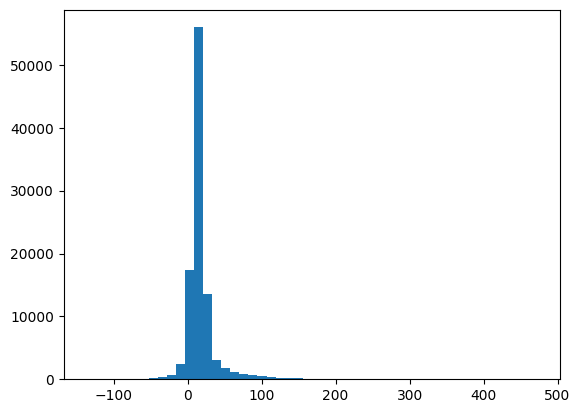

In [41]:
r = constrainedOptimalFilter(data[:,:7])

err = (r - data[:,7])


plt.hist(err, bins=50)